# Profiling Lidar Mission Planning

**Purpose:** This notebook walks through HyPlan's `ProfilingLidar` family — nadir-pointing single-beam airborne lidars that record vertical atmospheric columns directly beneath the platform. Three concrete instruments are modeled, all built or operated by NASA:

- **HSRL-2** — NASA Langley High Spectral Resolution Lidar, 3 wavelengths (355/532/1064 nm), 200 Hz Fibertek Nd:YAG, 40 cm telescope. Aerosol/cloud backscatter and extinction.
- **HALO** — NASA Langley High Altitude Lidar Observatory, 4 wavelengths (532/935/1064/1645 nm), 1 kHz laser, 40 cm telescope. Adds water-vapor and methane DIAL/IPDA. HSRL-2's successor.
- **CPL** — NASA Goddard Cloud Physics Lidar, 3 wavelengths (355/532/1064 nm), 5 kHz photon-counting, 20 cm telescope. High-PRF cirrus/aerosol profiler designed for high-altitude platforms.

The Doppler wind profiler family (e.g., AWP) is **not** part of this hierarchy — its dual-LOS geometry is modeled separately. See `notebooks/awp_planning.ipynb`.

| | |
|---|---|
| **Audience** | Intermediate |
| **Runtime** | < 1 minute |
| **Requires internet** | No |
| **Credentials required** | None |
| **Optional dependencies** | None |
| **Uses example data** | No |

**What You Will Learn:**
- The shared `ProfilingLidar` API and how three very different operating regimes (200 Hz vs 1 kHz vs 5 kHz pulse rate, 40 cm vs 20 cm telescopes, 0.8 mrad vs 100 μrad divergence) all fit it
- How nadir laser footprint diameter scales with platform altitude — and why CPL's 100 μrad beam gives much smaller footprints than HSRL-2's 0.8 mrad
- How sampling rate, pulse rate, and post-processing averaging interact to set effective horizontal resolution
- How the same instrument produces different along-track sampling on different aircraft
- How to model variants (e.g., HSRL-1 from `HSRL2`, HALO transmitter modes) by overriding constructor defaults

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyplan.instruments import HSRL2, HALO, CPL, ProfilingLidar, create_sensor
from hyplan.aircraft import KingAirB200, NASA_P3, NASA_GIII, NASA_GV, NASA_ER2
from hyplan.units import ureg

INSTRUMENTS = [HSRL2(), HALO(), CPL()]

## 1. Family Overview

Each `ProfilingLidar` exposes the same six attributes (wavelengths, pulse rate, telescope diameter, beam divergence, vertical resolution, sampling rate) plus an optional native horizontal resolution. The table below shows how the three modeled instruments compare across these dimensions. Some HALO values are deliberately `None` (`beam_divergence`, `native_horizontal_resolution`) because the published literature doesn't tabulate them — `footprint_diameter()` raises a clear error rather than inventing a default.

In [2]:
def fmt_q(q, unit, fmt=".1f"):
    if q is None:
        return "—"
    return format(q.to(unit).magnitude, fmt) + f" {unit}"


rows = []
for s in INSTRUMENTS:
    rows.append({
        "Instrument": s.name,
        "Wavelengths (nm)": ", ".join(f"{w.m_as('nanometer'):.0f}" for w in s.wavelengths),
        "Pulse rate": fmt_q(s.pulse_rate, "hertz", ".0f"),
        "Sampling rate": fmt_q(s.sampling_rate, "hertz", ".1f"),
        "Telescope": fmt_q(s.telescope_diameter, "centimeter", ".1f"),
        "Beam divergence": fmt_q(s.beam_divergence, "microradian", ".0f") if s.beam_divergence else "—",
        "Vertical res.": fmt_q(s.vertical_resolution, "meter", ".0f"),
        "Native h-res.": fmt_q(s.native_horizontal_resolution, "meter", ".0f") if s.native_horizontal_resolution else "—",
    })

pd.DataFrame(rows).set_index("Instrument")

,Wavelengths (nm),Pulse rate,Sampling rate,Telescope,Beam divergence,Vertical res.,Native h-res.
Instrument,,,,,,,
HSRL-2,"355, 532, 1064",200 hertz,2.0 hertz,40.6 centimeter,800 microradian,15 meter,100 meter
HALO,"532, 935, 1064, 1645",1000 hertz,2.0 hertz,40.0 centimeter,—,15 meter,—
CPL,"355, 532, 1064",5000 hertz,1.0 hertz,20.0 centimeter,100 microradian,30 meter,200 meter


## 2. Footprint Diameter vs Platform Altitude

For a nadir-pointing pencil-beam lidar, the footprint on the ground is set by beam divergence and altitude AGL:

$$d_\mathrm{footprint} = h_\mathrm{AGL} \cdot \theta_\mathrm{divergence}$$

The two instruments with published divergence span a wide range:
- **HSRL-2**: 0.8 mrad — relatively wide beam (HSRL-1 heritage; large-aperture telescope is paired with a wider transmit beam)
- **CPL**: 100 μrad — eight times narrower, designed for the tighter receive FOV needed by photon counting at high altitude

HALO doesn't publish a beam divergence value, so it's omitted from the plot. To see HALO's footprint, override `beam_divergence` at construction with a campaign-specific value.

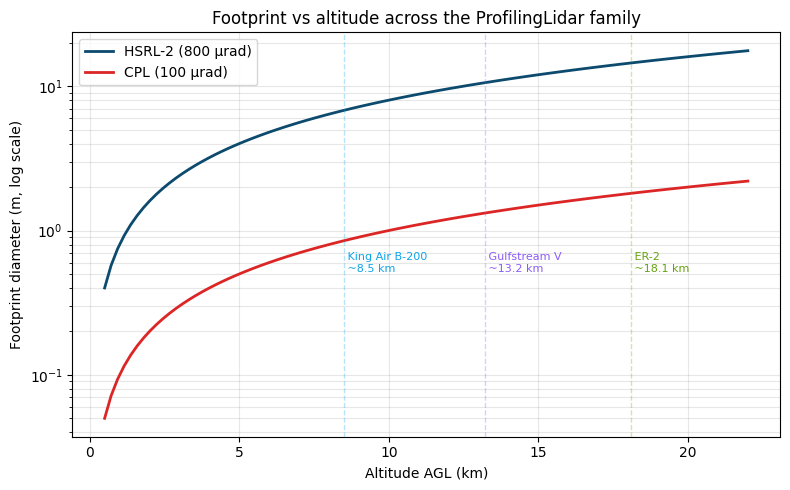

Footprint at typical ER-2 altitude (~18 km AGL):
  HSRL-2  : 14.4 m
  CPL     : 1.8 m


In [3]:
altitudes_km = np.linspace(0.5, 22, 100)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"HSRL-2": "#0c4a6e", "CPL": "#dc2626"}
for sensor in INSTRUMENTS:
    if sensor.beam_divergence is None:
        continue
    footprints_m = [
        sensor.footprint_diameter(h * ureg.kilometer).m_as("meter")
        for h in altitudes_km
    ]
    ax.plot(altitudes_km, footprints_m,
            color=colors[sensor.name], linewidth=2,
            label=f"{sensor.name} ({sensor.beam_divergence.m_as('microradian'):.0f} μrad)")

# Mark typical platform altitudes
platforms = [
    ("King Air B-200", 8.5, "#0ea5e9"),
    ("Gulfstream V", 13.2, "#8b5cf6"),
    ("ER-2", 18.1, "#65a30d"),
]
for name, alt, color in platforms:
    ax.axvline(alt, color=color, alpha=0.3, linestyle="--", linewidth=1)
    ax.text(alt, 0.5, f" {name}\n ~{alt:.1f} km", color=color, fontsize=8,
            verticalalignment="bottom")

ax.set_yscale("log")
ax.set_xlabel("Altitude AGL (km)")
ax.set_ylabel("Footprint diameter (m, log scale)")
ax.set_title("Footprint vs altitude across the ProfilingLidar family")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

print("Footprint at typical ER-2 altitude (~18 km AGL):")
for s in INSTRUMENTS:
    if s.beam_divergence is not None:
        d = s.footprint_diameter(18 * ureg.kilometer)
        print(f"  {s.name:8s}: {d:~.1f}")

## 3. Pulse Rate and Pulses-per-Profile

The three instruments span a 25× range in pulse repetition rate:
- **HSRL-2**: 200 Hz (HSRL-1 heritage Fibertek Nd:YAG)
- **HALO**: 1 kHz (newer-generation laser supporting DIAL channels)
- **CPL**: 5 kHz (low-pulse-energy, photon-counting design for compactness)

Higher PRF means more pulses averaged into each retrieval profile at any given averaging window — the primary source of HALO and CPL's noise advantage over HSRL-2 at short integration times.

In [4]:
averaging_times_s = [0.5, 1, 2, 5, 10, 15, 30, 60]

rows = []
for s in INSTRUMENTS:
    row = {"Instrument": f"{s.name} ({s.pulse_rate:~.0f})"}
    for t_s in averaging_times_s:
        row[f"{t_s} s"] = s.pulses_per_profile(t_s * ureg.second)
    rows.append(row)

pulse_table = pd.DataFrame(rows).set_index("Instrument")
pulse_table

,0.5 s,1 s,2 s,5 s,10 s,15 s,30 s,60 s
Instrument,,,,,,,,
HSRL-2 (200 Hz),100,200,400,1000,2000,3000,6000,12000
HALO (1000 Hz),500,1000,2000,5000,10000,15000,30000,60000
CPL (5000 Hz),2500,5000,10000,25000,50000,75000,150000,300000


## 4. Horizontal Resolution from Averaging Window and Aircraft Speed

Because all three instruments record continuously, effective horizontal resolution is set by the post-processing averaging window times ground speed. The same instrument produces wildly different sampling on a slow King Air vs a fast Gulfstream vs the ER-2. The plot below traces this for a representative spread of cruise speeds.

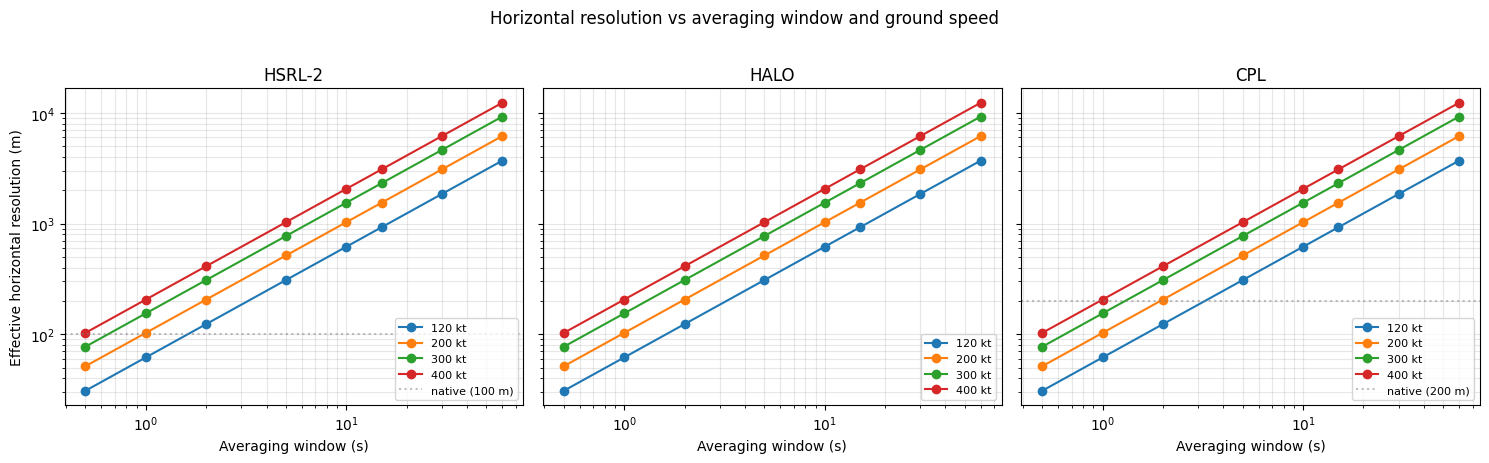

In [5]:
windows_s = np.array([0.5, 1, 2, 5, 10, 15, 30, 60])
speeds_kt = [120, 200, 300, 400]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, sensor in zip(axes, INSTRUMENTS):
    for v_kt in speeds_kt:
        speed = v_kt * ureg.knot
        h_res_m = [
            sensor.horizontal_resolution(speed, t * ureg.second).m_as("meter")
            for t in windows_s
        ]
        ax.plot(windows_s, h_res_m, marker="o", label=f"{v_kt} kt")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Averaging window (s)")
    ax.set_title(sensor.name)
    ax.grid(alpha=0.3, which="both")
    if sensor.native_horizontal_resolution is not None:
        ax.axhline(sensor.native_horizontal_resolution.m_as("meter"),
                   color="grey", linestyle=":", alpha=0.5,
                   label=f"native ({sensor.native_horizontal_resolution:~.0f})")
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("Effective horizontal resolution (m)")
fig.suptitle("Horizontal resolution vs averaging window and ground speed", y=1.02)
plt.tight_layout()
plt.show()

## 5. Aircraft Platform Comparison

Each instrument has flown on a different mix of NASA aircraft. The table below shows, for one representative aircraft per instrument, the typical operating altitude, footprint at that altitude, and effective horizontal resolution at the published native or commonly-cited averaging window.

In [6]:
scenarios = [
    # (instrument, aircraft, typical_window, label)
    (HSRL2(), KingAirB200(), 10 * ureg.second, "Müller 2014 ~10 s"),
    (HSRL2(), NASA_GV(),     10 * ureg.second, "Müller 2014 ~10 s"),
    (HALO(),  NASA_P3(),     15 * ureg.second, "Carroll 2022 ACT-America"),
    (HALO(),  NASA_GIII(),   15 * ureg.second, "Carroll 2022 ACT-America"),
    (CPL(),   NASA_ER2(),    1 * ureg.second,  "McGill 2002 standard"),
]

rows = []
for sensor, aircraft, window, label in scenarios:
    typical_alt = (0.85 * aircraft.service_ceiling).to(ureg.foot)
    cruise_tas = aircraft.cruise_speed_at(typical_alt)
    altitude_km = typical_alt.to(ureg.kilometer).magnitude
    h_res = sensor.horizontal_resolution(cruise_tas, window)
    row = {
        "Instrument": sensor.name,
        "Aircraft": aircraft.aircraft_type,
        "Altitude": f"{typical_alt:~.0f} ({altitude_km:.1f} km)",
        "Cruise TAS": f"{cruise_tas.to(ureg.knot):~.0f}",
        "Window": f"{window:~.0f} ({label})",
        "H-res": f"{h_res.to(ureg.kilometer):~.2f}",
        "Pulses/profile": sensor.pulses_per_profile(window),
    }
    if sensor.beam_divergence is not None:
        row["Footprint"] = f"{sensor.footprint_diameter(altitude_km * ureg.kilometer):~.1f}"
    else:
        row["Footprint"] = "—"
    rows.append(row)

pd.DataFrame(rows)

,Instrument,Aircraft,Altitude,Cruise TAS,Window,H-res,Pulses/profile,Footprint
0,HSRL-2,King Air 200,29750 ft (9.1 km),240 kt,10 s (Müller 2014 ~10 s),1.24 km,2000,7.3 m
1,HSRL-2,Gulfstream V,43350 ft (13.2 km),459 kt,10 s (Müller 2014 ~10 s),2.36 km,2000,10.6 m
2,HALO,P-3 Orion,27200 ft (8.3 km),301 kt,15 s (Carroll 2022 ACT-America),2.32 km,15000,—
3,HALO,Gulfstream III,38250 ft (11.7 km),434 kt,15 s (Carroll 2022 ACT-America),3.35 km,15000,—
4,CPL,ER-2,59500 ft (18.1 km),387 kt,1 s (McGill 2002 standard),0.20 km,5000,1.8 m


## 6. Modeling Variants via Constructor Overrides

Every constructor argument is keyword-overridable, so users can model variants without subclassing.

### HSRL-1 from `HSRL2`

HSRL-1 is the predecessor to HSRL-2 and operated at only two wavelengths (no 355 nm channel, no Michelson interferometer). Drop the 355 nm entry to get a planning model for it.

In [7]:
hsrl1 = HSRL2(
    name="HSRL-1",
    wavelengths=(532 * ureg.nanometer, 1064 * ureg.nanometer),
)
print(f"{hsrl1.name}: wavelengths = {', '.join(f'{w:~.0f}' for w in hsrl1.wavelengths)}")
print(f"          (other parameters inherited from HSRL-2 defaults — same Fibertek laser, same 40 cm telescope)")

HSRL-1: wavelengths = 532 nm, 1064 nm
          (other parameters inherited from HSRL-2 defaults — same Fibertek laser, same 40 cm telescope)


### HALO transmitter modes

HALO is reconfigurable across three transmitter combinations sharing a common multi-channel receiver. The default `HALO()` lists all four channels; override `wavelengths` to model a specific mode.

In [8]:
halo_modes = {
    "CH4 DIAL + HSRL":    (532, 1064, 1645),
    "H2O DIAL + HSRL":    (532, 935, 1064),
    "CH4 DIAL + H2O DIAL":(935, 1064, 1645),
}

for mode, wls in halo_modes.items():
    sensor = HALO(
        name=f"HALO ({mode})",
        wavelengths=tuple(w * ureg.nanometer for w in wls),
    )
    print(f"{sensor.name}")
    print(f"  active channels: {', '.join(f'{w:.0f} nm' for w in wls)}")

HALO (CH4 DIAL + HSRL)
  active channels: 532 nm, 1064 nm, 1645 nm
HALO (H2O DIAL + HSRL)
  active channels: 532 nm, 935 nm, 1064 nm
HALO (CH4 DIAL + H2O DIAL)
  active channels: 935 nm, 1064 nm, 1645 nm


### Supplying beam divergence for HALO

HALO doesn't publish a beam divergence value, so `footprint_diameter()` raises by default. Users with campaign-specific divergence data can supply it at construction:

In [9]:
# Default HALO has no divergence — footprint_diameter raises
default_halo = HALO()
try:
    default_halo.footprint_diameter(8 * ureg.kilometer)
except Exception as e:
    print(f"Default: raises {type(e).__name__}: {e}\n")

# Supply HSRL-heritage divergence as a planning approximation
halo_planning = HALO(beam_divergence=0.8 * ureg.milliradian)
print(f"With 0.8 mrad assumed: footprint at 8 km AGL = "
      f"{halo_planning.footprint_diameter(8 * ureg.kilometer):~.1f}")

Default: raises HyPlanValueError: footprint_diameter requires beam_divergence to be set on HALO; no published default for this instrument

With 0.8 mrad assumed: footprint at 8 km AGL = 6.4 m


## 7. Custom `ProfilingLidar` Instances

For instruments not yet pre-configured (e.g., ROSCOE, future profiling lidars), the base `ProfilingLidar` class can be instantiated directly. All required parameters must be supplied; optional ones default to `None`.

In [10]:
# Hypothetical custom profiling lidar — illustrating direct base-class construction
custom = ProfilingLidar(
    "Hypothetical Profiler",
    wavelengths=(532 * ureg.nanometer, 1064 * ureg.nanometer),
    pulse_rate=10 * ureg.kilohertz,
    telescope_diameter=15 * ureg.centimeter,
    vertical_resolution=10 * ureg.meter,
    sampling_rate=10 * ureg.hertz,
    beam_divergence=50 * ureg.microradian,
)

print(f"{custom.name}")
print(f"  pulses per 1 s profile: {custom.pulses_per_profile(1 * ureg.second):,d}")
print(f"  footprint @ 20 km AGL:  {custom.footprint_diameter(20 * ureg.kilometer):~.2f}")
print(f"  h-res @ 200 m/s, 1 s:   {custom.horizontal_resolution(200 * ureg.meter / ureg.second, 1 * ureg.second):~.0f}")

Hypothetical Profiler
  pulses per 1 s profile: 10,000
  footprint @ 20 km AGL:  1.00 m
  h-res @ 200 m/s, 1 s:   200 m


## 8. Factory Registration

Each pre-configured instrument is registered with HyPlan's sensor factory under multiple aliases — useful when sensor types come from string-valued config files.

In [11]:
aliases = {
    HSRL2: ["HSRL-2", "HSRL2", "HSRL"],
    HALO:  ["HALO", "High Altitude Lidar Observatory"],
    CPL:   ["CPL", "Cloud Physics Lidar"],
}

for cls, names in aliases.items():
    for alias in names:
        sensor = create_sensor(alias)
        ok = "✓" if isinstance(sensor, cls) else "✗"
        print(f"  {ok} create_sensor({alias!r:36s}) -> {type(sensor).__name__}")

  ✓ create_sensor('HSRL-2'                            ) -> HSRL2
  ✓ create_sensor('HSRL2'                             ) -> HSRL2
  ✓ create_sensor('HSRL'                              ) -> HSRL2
  ✓ create_sensor('HALO'                              ) -> HALO
  ✓ create_sensor('High Altitude Lidar Observatory'   ) -> HALO
  ✓ create_sensor('CPL'                               ) -> CPL
  ✓ create_sensor('Cloud Physics Lidar'               ) -> CPL


## References

1. **Müller, D., Hostetler, C. A., Ferrare, R. A., Burton, S. P., et al. (2014).** Airborne Multiwavelength High Spectral Resolution Lidar (HSRL-2) Observations during TCAP 2012. *Atmos. Meas. Tech.*, 7, 3487-3496. https://doi.org/10.5194/amt-7-3487-2014

2. **Hair, J. W., et al. (2008).** Airborne High Spectral Resolution Lidar for profiling aerosol optical properties. *Applied Optics*, 47(36), 6734-6752. https://doi.org/10.1364/AO.47.006734

3. **Burton, S. P., et al. (2018).** Calibration of a high spectral resolution lidar using a Michelson interferometer, with data examples from ORACLES. *Applied Optics*, 57(21), 6061-6075. https://doi.org/10.1364/AO.57.006061

4. **Carroll, B. J., Nehrir, A. R., Kooi, S. A., et al. (2022).** Evaluation of the High Altitude Lidar Observatory (HALO) methane retrievals during the summer 2019 ACT-America campaign. *Atmos. Meas. Tech.*, 15, 4623-4650. https://doi.org/10.5194/amt-15-4623-2022

5. **McGill, M., et al. (2002).** Cloud Physics Lidar: instrument description and initial measurement results. *Applied Optics*, 41(18), 3725-3734. https://doi.org/10.1364/AO.41.003725